In [1]:
import polars as pl
import joblib
from pathlib import Path
from glob import glob
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

# Apply shared publication style
import sys; sys.path.insert(0, str(Path('.').resolve()))
from pub_style import (apply_style, add_panel_label, savefig,
                        FONT_SIZE_TITLE, FONT_SIZE_AXIS_LABEL,
                        FONT_SIZE_LEGEND, DOUBLE_COL_IN)
apply_style()

# Point to the data/ directory at repo root (download S3 data there)
DATA_DIR = Path('../data')

MANUSCRIPT_FIG_DIR = Path('../manuscript/figures')
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)

def _sanitize_col(c):
    return re.sub(r'[\[\]<>]', '_', c)

In [2]:
site_mapping = {
    'bidmc':'BIDMC',
    'stan':'Stanford',
    'emory':'Emory',
    'bch':'BCH',
    'mgb':'MGH',
    'BIDMC': 'BIDMC',
    'Stanford': 'Stanford',
    'Emory': 'Emory',
    'BCH': 'BCH',
    'MGB': 'MGH',
}
model_type_mapping = {
    'nt1':'NT1',
    'nt2ih':'NT2/IH',
    'any_narcolepsy': 'Any Narcolepsy',
}

# Label maps for each task (must match retrain_all.py)
label_maps = {
    'nt1': pl.when(pl.col('annot') == 1).then(1).otherwise(0),
    'nt2ih': pl.when(pl.col('annot') == 2).then(1).otherwise(0),
    'any_narcolepsy': pl.when(pl.col('annot').is_in([1, 2, 3])).then(1).otherwise(0),
}

In [3]:
def plot_confusion_matrices(models, feat, site_mapping, model_type, save_path=None):
    # Add binary label column using label_maps
    feat = feat.with_columns(label_maps[model_type].alias(model_type))

    # Determine which sites have data with both classes
    valid_sites = []
    for k in sorted(models.keys()):
        sub_feat = feat.filter(pl.col('cohort') == k)
        if len(sub_feat) == 0:
            continue
        y = sub_feat[model_type].to_numpy()
        if len(np.unique(y)) < 2:
            continue
        valid_sites.append(k)

    n_sites = len(valid_sites)
    if n_sites == 0:
        print(f'  No valid sites for {model_type}, skipping.')
        return

    n_cols = min(n_sites, 3)
    n_rows = (n_sites + n_cols - 1) // n_cols
    # Add one extra slot for colorbar
    total_slots = n_rows * n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(DOUBLE_COL_IN, 2.5 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    axes_flat = axes.flatten()

    panel_labels = [chr(ord('A') + i) for i in range(n_sites)]

    for idx, k in enumerate(valid_sites):
        model = models[k]
        expected_features = list(model.feature_names_in_)
        sub_feat = feat.filter(pl.col('cohort') == k)
        y = sub_feat[model_type].to_numpy()

        # Select and rename features to match model training
        X_cols = sub_feat.drop(['annot', 'cohort', 'id', 'date', model_type])
        rename_map = {c: _sanitize_col(c) for c in X_cols.columns if _sanitize_col(c) != c}
        if rename_map:
            X_cols = X_cols.rename(rename_map)
        # Only select features that exist in both model and data
        available = [f for f in expected_features if f in X_cols.columns]
        if len(available) < len(expected_features):
            # Fill missing features with 0
            missing = [f for f in expected_features if f not in X_cols.columns]
            for mf in missing:
                X_cols = X_cols.with_columns(pl.lit(0).alias(mf))
        X = X_cols.select(expected_features)

        y_pred = model.predict(X)
        cm = confusion_matrix(y, y_pred)

        # Calculate percentages
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

        # Create custom annotations with percentage and counts
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f'{cm_percent[i, j]:.1f}%\n({cm[i, j]})'

        add_panel_label(axes_flat[idx], panel_labels[idx])
        sns.heatmap(cm_percent, annot=annot, fmt='', cmap='Blues', ax=axes_flat[idx],
                    vmin=0, vmax=100, cbar=False, annot_kws={'fontsize': 9})
        axes_flat[idx].set_title(f'Test site: {site_mapping[k]}')
        axes_flat[idx].set_xlabel('Predicted label')
        axes_flat[idx].set_ylabel('True label')

    # Hide unused subplots and add colorbar in last one
    for j in range(n_sites, total_slots):
        axes_flat[j].axis('off')
    if total_slots > n_sites:
        cbar = fig.colorbar(axes_flat[0].collections[0], ax=axes_flat[-1], fraction=0.8)
        cbar.set_label('Percentage (%)')

    plt.tight_layout()

    if save_path:
        savefig(fig, str(save_path))
        print(f'Saved: {save_path}')

    plt.show()

In [4]:
# Load features — keep annot=3 (needed for any_narcolepsy task)
# NT1/NT2 tasks filter via label_maps (annot=3 → negative, which is fine)
features = pl.read_parquet(DATA_DIR / 'discriminative-modeling/features.parquet').hstack(
    pl.read_parquet(DATA_DIR / 'discriminative-modeling/notes.parquet').select('annot', 'cohort')
).select(
    'id','date','cohort','annot', pl.all().exclude(['id','date','cohort','annot'])
)

In [5]:
features

id,date,cohort,annot,^347\.?[0|1]1|^G47\.?4[1|2]1,^347\.?[0|1]0|^G47\.?4[1|2]9,^G47\.?1|^327\.?1[1|2],^G47\.?3|^327\.?2[3|7],adderall,clomipramine,dextroamphetamine,duloxetine,effexor,fluoxetine,imipramine,modafinil,nuvigil,paroxetine,pitolisant,protriptyline,provigil,sertraline,sodium oxybate,solriamfetol,venlafaxine,50 improv_,abnorm_,abnorm find_,abnorm glucos_,abnorm weight_,activ_,adderal_,adderal xr_,alcohol_,alcohol avoid_,ambien_,amitriptylin_,…,trial_neg_,trial adderal_neg_,type_neg_,type walk_neg_,unrefresh_neg_,unrefresh sleep_neg_,use_neg_,venlafaxin_neg_,visit_neg_,vivid_neg_,vivid dream_neg_,wake_neg_,wake test_neg_,walk_neg_,walk 30_neg_,walk activ_neg_,watch_neg_,weak_neg_,wean_neg_,week_neg_,weight_neg_,weight decreas_neg_,weight discuss_neg_,weight gain_neg_,weight increas_neg_,weight loss_neg_,weight mainten_neg_,weight manag_neg_,work_neg_,work diet_neg_,work routin_neg_,worri_neg_,xr_neg_,xyrem_neg_,yes_neg_,zanaflex_neg_,zoloft_neg_
str,date,str,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""175065367""",2017-01-13,"""BCH""",1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""177502328""",2016-12-06,"""Stanford""",4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
"""179001059""",2019-02-26,"""Emory""",4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,…,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"""179014009""",2018-01-15,"""Emory""",4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,…,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""179013058""",2019-03-20,"""Emory""",4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,…,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""150024379""",2017-02-02,"""BIDMC""",2,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""150022556""",2011-05-10,"""BIDMC""",1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
"""114676109""",2023-02-02,"""MGB""",2,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,…,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [6]:
# Load all models for all 3 tasks
all_task_models = {}
for task in ['nt1', 'nt2ih', 'any_narcolepsy']:
    results_dir = DATA_DIR / f'results/{task}_vs_others'
    model_comparison = {}
    for model_name in ['LogisticRegression', 'GradientBoosting', 'RandomForest', 'XGBoost']:
        models = {}
        for m in glob(str(results_dir / f'fold_models_{model_name}/*.pkl')):
            site_key = m.split('/')[-1].split('_')[-1].split('.')[0]
            models[site_key] = joblib.load(m)
        if models:
            model_comparison[model_name] = models
    all_task_models[task] = model_comparison
    print(f'{task}: loaded {list(model_comparison.keys())}')

nt1: loaded ['LogisticRegression', 'GradientBoosting', 'RandomForest', 'XGBoost']
nt2ih: loaded ['LogisticRegression', 'GradientBoosting', 'RandomForest', 'XGBoost']
any_narcolepsy: loaded ['LogisticRegression', 'GradientBoosting', 'RandomForest', 'XGBoost']


Plotting NT1 confusion matrices for LogisticRegression...


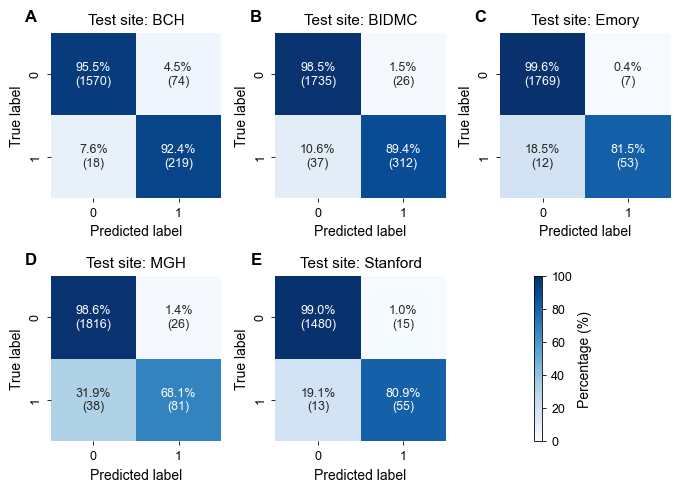

Plotting NT1 confusion matrices for GradientBoosting...


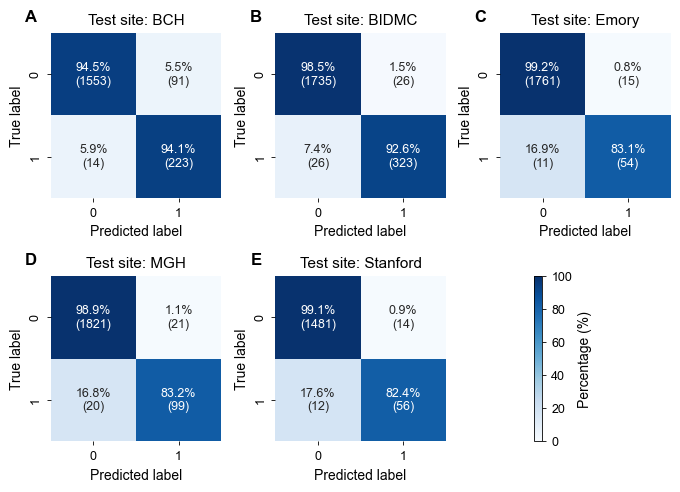

Plotting NT1 confusion matrices for RandomForest...


Saved: ../manuscript/figures/efigure6_nt1_confusion_matrices.png


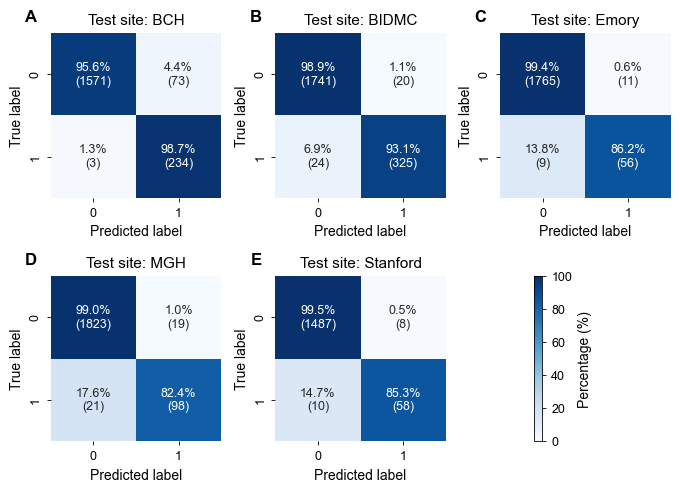

Plotting NT1 confusion matrices for XGBoost...


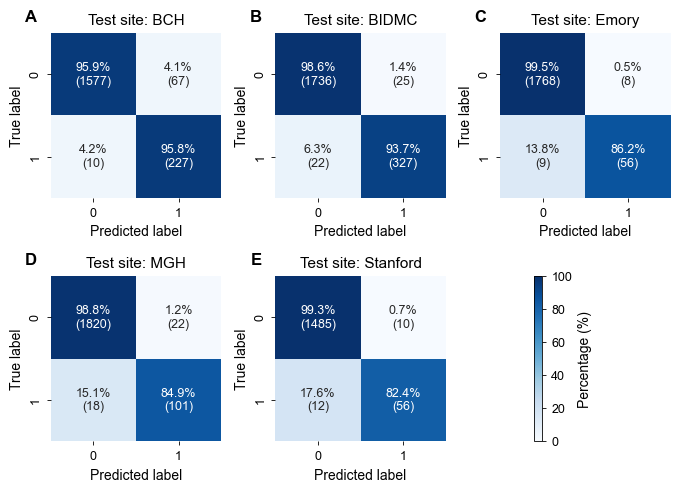

In [7]:
# Best NT1 model is RandomForest (eFigure 6)
for model_name, models in all_task_models['nt1'].items():
    save_path = None
    if model_name == 'RandomForest':
        save_path = MANUSCRIPT_FIG_DIR / 'efigure6_nt1_confusion_matrices.png'
    print(f'Plotting NT1 confusion matrices for {model_name}...')
    plot_confusion_matrices(models, features, site_mapping, 'nt1', save_path=save_path)

Plotting NT2/IH confusion matrices for LogisticRegression...


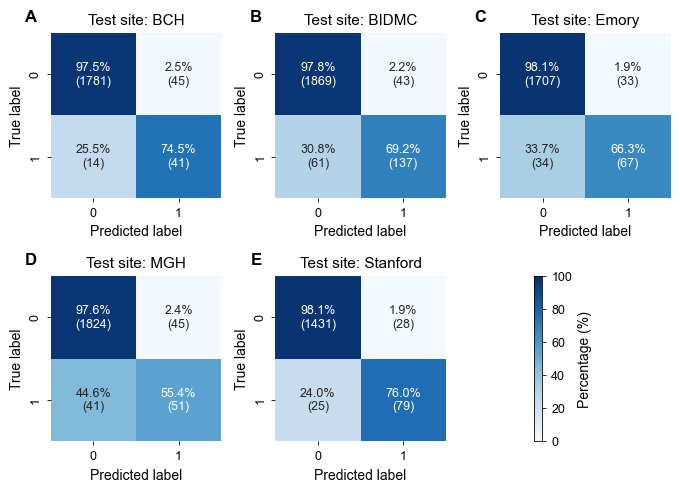

Plotting NT2/IH confusion matrices for GradientBoosting...


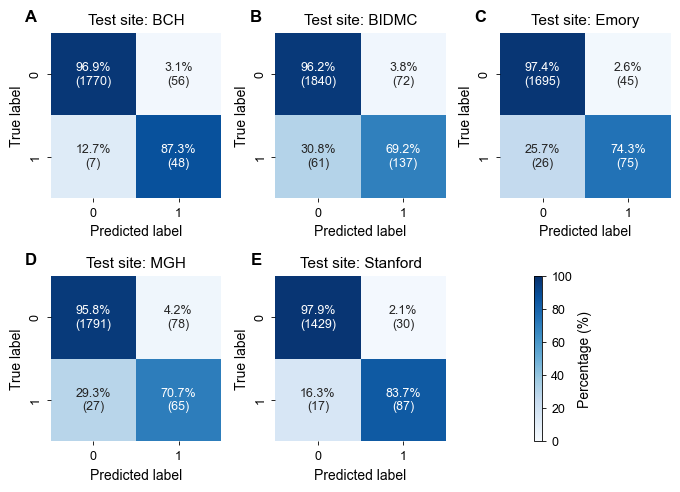

Plotting NT2/IH confusion matrices for RandomForest...


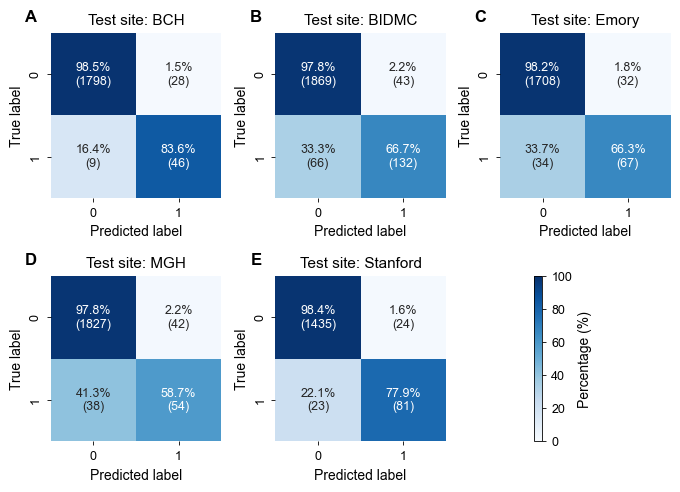

Plotting NT2/IH confusion matrices for XGBoost...


Saved: ../manuscript/figures/efigure7_nt2ih_confusion_matrices.png


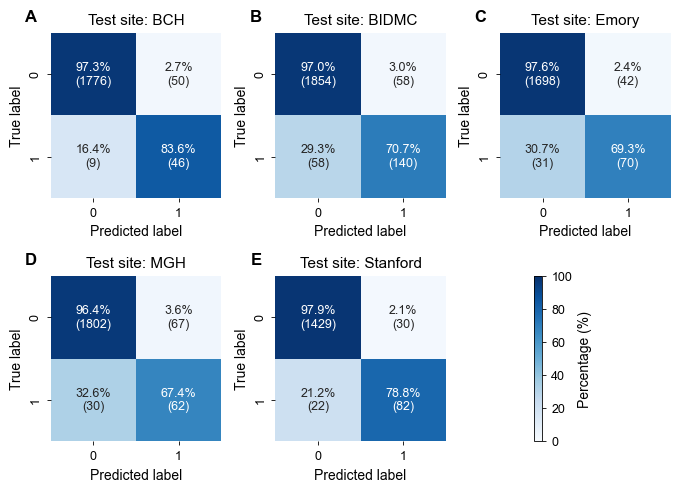

In [8]:
# Best NT2/IH model is XGBoost (eFigure 7)
for model_name, models in all_task_models['nt2ih'].items():
    save_path = None
    if model_name == 'XGBoost':
        save_path = MANUSCRIPT_FIG_DIR / 'efigure7_nt2ih_confusion_matrices.png'
    print(f'Plotting NT2/IH confusion matrices for {model_name}...')
    plot_confusion_matrices(models, features, site_mapping, 'nt2ih', save_path=save_path)

Plotting Any Narcolepsy confusion matrices for LogisticRegression...


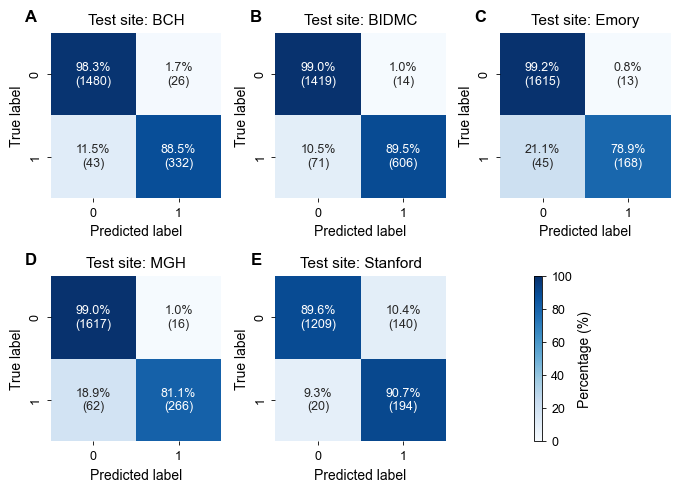

Plotting Any Narcolepsy confusion matrices for GradientBoosting...


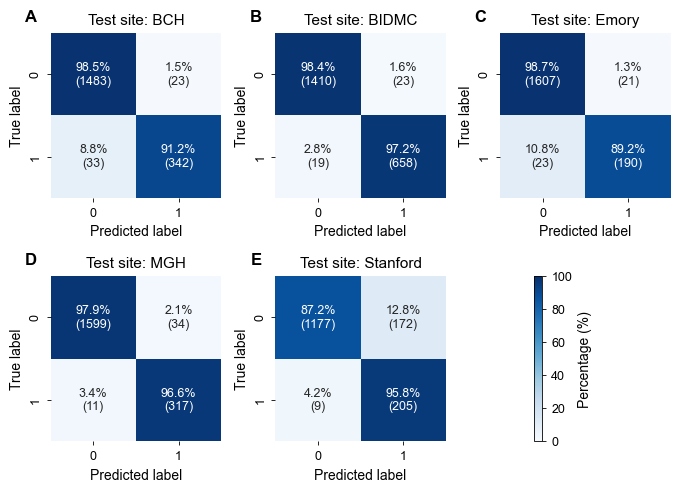

Plotting Any Narcolepsy confusion matrices for RandomForest...


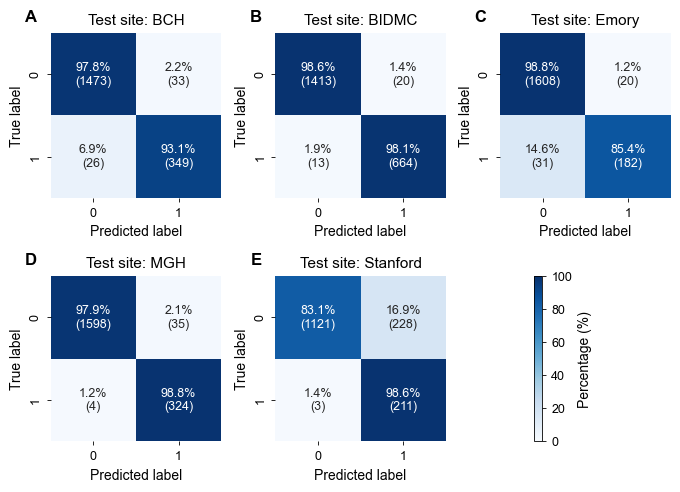

Plotting Any Narcolepsy confusion matrices for XGBoost...


Saved: ../manuscript/figures/efigure8_any_narcolepsy_confusion_matrices.png


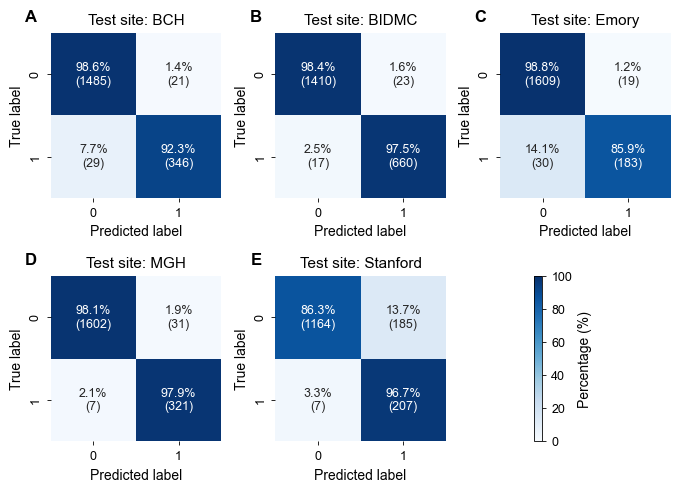

In [9]:
# Best Any Narcolepsy model is XGBoost (eFigure 8)
for model_name, models in all_task_models['any_narcolepsy'].items():
    save_path = None
    if model_name == 'XGBoost':
        save_path = MANUSCRIPT_FIG_DIR / 'efigure8_any_narcolepsy_confusion_matrices.png'
    print(f'Plotting Any Narcolepsy confusion matrices for {model_name}...')
    plot_confusion_matrices(models, features, site_mapping, 'any_narcolepsy', save_path=save_path)